### Generación de ground truth — Navier–Stokes estocástico 2D (forma de vorticidad)

$$
\boxed{dX_t = \big(\nu\,\Delta X_t \;-\; U[X_t]\!\cdot\!\nabla X_t \;+\; f\big)\,dt \;+\; \sigma\,dW_t,
\qquad (t,x)\in[0,T]\times\mathbb{T}^2,\quad X_0=\chi_0}
$$

donde $X_t=w$ es la **vorticidad**, $U[X_t]=\nabla^\perp(-\Delta)^{-1}X_t$ la velocidad inducida
($\nabla^\perp=(-\partial_{x_2},\partial_{x_1})$), $\nu$ la viscosidad, $f$ un forzamiento determinista
y $\sigma\,dW$ un forzamiento estocástico $Q$-Browniano (coloreado en espacio).

**Referencias del método.** Sigue el Apéndice F.2 de Shi et al. (2026) — "*Expanding the Chaos*" —, que a su
vez sigue a Salvi et al. (2022, *Neural SPDEs*) y reutiliza el solver del repositorio
[`torchspde`](https://github.com/crispitagorico/torchspde) (`data/generator_sns.py`, `data/random_forcing.py`),
adaptado de [`fourier_neural_operator`](https://github.com/zongyi-li/fourier_neural_operator) (Li et al. 2020).

**Método numérico** (igual que para $\Phi^4_1$ adoptamos diferencias finitas de `torchspde`, aquí adoptamos
su esquema **pseudo-espectral**):

> 1. **Solver:** pseudo-espectral con paso temporal **Crank–Nicolson** (difusión $\nu\Delta$ implícita,
>    término no lineal $U\!\cdot\!\nabla w$ y forzamientos explícitos), regla de **dealiasing 2/3**.
>    Todo se calcula en el dominio de Fourier salvo el producto no lineal (en espacio físico).
> 2. **Ruido:** $Q$-Browniano por expansión de Karhunen–Loève en modos de Fourier 2D, con
>    autovalores $\sqrt{q_k}=\exp(-\alpha_n|\,2\pi k\,|^2/2)$ (decaimiento espectral $\Rightarrow$ ruido
>    suave, dominado por modos bajos). El incremento $dW_n(x)$ es real con simetría hermítica.
> 3. **Condición inicial:** campo aleatorio gaussiano (GRF) $\chi_0\sim\mathcal N\!\big(0,\,\tau^{2\alpha-d}(-\Delta+\tau^2 I)^{-\alpha}\big)$
>    con $\alpha=3,\ \tau=3$ (exactamente la CI de Salvi/torchspde).

**Dos tareas** (como en $\Phi^4_1$ y en la Table 2 del paper):
- $W\mapsto X$: CI **fija** (una única muestra GRF compartida); sólo varía el ruido.
- $(X_0,W)\mapsto X$: CI **variable** (una muestra GRF por trayectoria) y ruido variable.

> **Nota de fidelidad / costo (CPU).** El paper usa $T=15$, $64\times64$ y GPU H200. Aquí, para que corra en
> CPU, usamos un horizonte corto $T$ (equivalente a una ventana de las que el paper recorta de las trayectorias
> largas, *à la* Salvi) y un ruido coloreado dominado por pocos modos espaciales, que es justo el régimen donde la
> expansión de Wiener–caos truncada es efectiva. Todos los parámetros están en la celda de configuración.

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(6)  # CPU

# ---------------- Parámetros (F.2 / torchspde, adaptados a CPU) ----------------
s        = 64       # resolución espacial (toro [0,1]^2)  -> grilla s x s
nu       = 1e-4     # viscosidad  (= 1/Re)            (paper: 1e-4)
T        = 0.5      # horizonte temporal              (ventana corta, ver nota)
dt       = 1e-3     # paso interno del solver         (paper: 1e-3)
rec      = 50       # nº de snapshots a guardar  -> Nt+1 = 51 puntos temporales
sigma    = 0.01     # intensidad del forzamiento estocástico   (paper F.2: 0.01; torchspde: 0.05)
alpha_n  = 0.02     # decaimiento espectral del ruido Q (mayor = más suave / pocos modos)
a        = (1.0, 1.0)  # tamaño del dominio L1 x L2

# GRF de la condición inicial (Salvi/torchspde: alpha=3, tau=3)
GRF_ALPHA, GRF_TAU = 3.0, 3.0

# Tamaños de los datasets  (configurables; principal driver de costo/memoria)
N_TRAIN, N_TEST = 400, 80
S_TR, S_TE = 2024, 7777   # semillas separadas train/test

Nt = rec
print(f"grilla {s}x{s} | T={T} dt={dt} -> {math.ceil(T/dt)} pasos internos, "
      f"{rec+1} snapshots | nu={nu} sigma={sigma} alpha_n={alpha_n}")


grilla 64x64 | T=0.5 dt=0.001 -> 500 pasos internos, 51 snapshots | nu=0.0001 sigma=0.01 alpha_n=0.02


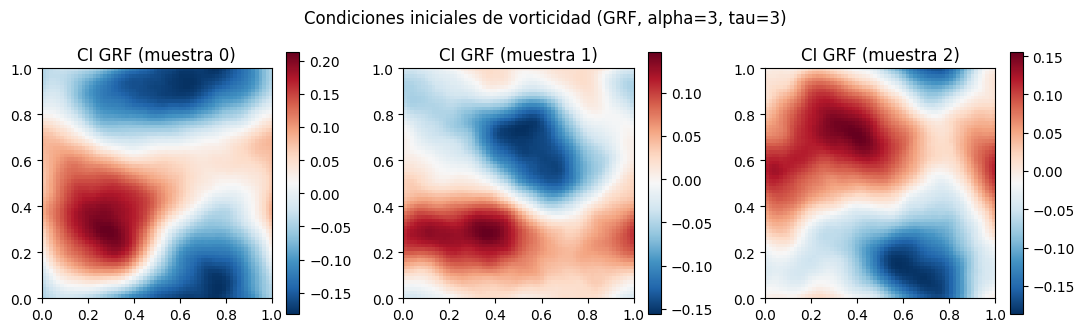

In [2]:
# ---------------- Condición inicial: Gaussian Random Field (GRF) ----------------
# chi0 ~ N(0, tau^(2*alpha-d) (-Lap + tau^2 I)^(-alpha))   (exactamente GaussianRF de torchspde)
def gaussian_rf(N, s, alpha=GRF_ALPHA, tau=GRF_TAU):
    sig = tau ** (0.5 * (2 * alpha - 2.0))          # d=2
    km = s // 2
    wn = torch.cat([torch.arange(0, km), torch.arange(-km, 0)]).repeat(s, 1)
    kx, ky = wn.t(), wn
    sqrt_eig = (s ** 2) * math.sqrt(2.0) * sig * (
        (4 * math.pi ** 2 * (kx ** 2 + ky ** 2) + tau ** 2) ** (-alpha / 2.0))
    sqrt_eig[0, 0] = 0.0                              # media cero (vorticidad sin componente uniforme)
    c = torch.randn(N, s, s, 2)
    c[..., 0] *= sqrt_eig; c[..., 1] *= sqrt_eig
    return torch.fft.ifftn(torch.view_as_complex(c), dim=[1, 2]).real

w0_demo = gaussian_rf(3, s)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
for i in range(3):
    im = ax[i].imshow(w0_demo[i], origin="lower", extent=[0, 1, 0, 1], cmap="RdBu_r")
    ax[i].set_title(f"CI GRF (muestra {i})"); fig.colorbar(im, ax=ax[i])
plt.suptitle("Condiciones iniciales de vorticidad (GRF, alpha=3, tau=3)")
plt.tight_layout(); plt.show()


In [3]:
# ---------------- Ruido Q-Browniano: raíz espectral (Karhunen-Loève en Fourier 2D) ----------------
# Covarianza Q diagonal en Fourier:  sqrt(q_k) = exp(-alpha_n |2 pi k|^2 / 2).
# El incremento dW_n(x) = ifft2( sqrt(q_k) Z sqrt(dt) ).real * s^2  es un campo REAL con
# covarianza espacial Q y varianza temporal dt por modo. (Modo (0,0) anulado.)
freq = torch.fft.fftfreq(s, d=1.0 / s)               # enteros 0,1,...,-1
lam = 2 * math.pi * freq
LXX, LYY = torch.meshgrid(lam, lam, indexing="ij")
root_q = torch.exp(-alpha_n * (LXX ** 2 + LYY ** 2) / 2)
root_q[0, 0] = 0.0

# Diagnóstico: ¿en qué modos vive la energía del ruido?  (justifica truncar pocos modos de Wick)
mag = root_q.numpy() ** 2
kk = np.sqrt((freq.numpy()[:, None] ** 2 + freq.numpy()[None, :] ** 2))
for kc in [1, 2, 3, 4, 6]:
    frac = mag[kk <= kc + 1e-9].sum() / mag.sum()
    print(f"energía de ruido en |k|<= {kc}:  {frac*100:5.1f}%")


energía de ruido en |k|<= 1:   61.0%
energía de ruido en |k|<= 2:   94.4%
energía de ruido en |k|<= 3:   99.9%
energía de ruido en |k|<= 4:  100.0%
energía de ruido en |k|<= 6:  100.0%


In [4]:
# ---------------- Solver pseudo-espectral Crank-Nicolson (port CPU de torchspde/generator_sns) ----------------
# Variables en Fourier; no linealidad U.grad(w) en espacio físico; difusión nu*Lap implícita (CN).
# Devuelve la solución w(t,x) y el ruido ACUMULADO W(t,x), ambos en la grilla de snapshots.
def navier_stokes_2d(w0, f, visc, T, dt, rec, root_q, sigma, a=a):
    M, N1, N2 = w0.shape
    km1, km2 = N1 // 2, N2 // 2
    steps = math.ceil(T / dt)
    w_h = torch.fft.fftn(w0, dim=[1, 2])
    f_h = torch.fft.fftn(f, dim=[-2, -1])[None]
    ky = torch.cat([torch.arange(0, km2), torch.arange(-km2, 0)]).repeat(N1, 1)
    kx = torch.cat([torch.arange(0, km1), torch.arange(-km1, 0)]).repeat(N2, 1).t()
    lap = 4 * math.pi ** 2 * (kx ** 2 / a[0] ** 2 + ky ** 2 / a[1] ** 2).float()
    lap[0, 0] = 1.0                                   # evita 0/0 al resolver Poisson (psi)
    deal = (torch.logical_and(torch.abs(ky) <= 2/3*km2,
                              torch.abs(kx) <= 2/3*km1).float())[None]   # dealiasing 2/3
    kxc = 2 * math.pi * 1j * kx / a[0]
    kyc = 2 * math.pi * 1j * ky / a[1]
    rt = max(steps // rec, 1)
    sol  = torch.zeros(M, rec + 1, N1, N2)
    Wcum = torch.zeros(M, rec + 1, N1, N2)
    sol[:, 0] = w0
    Wrun = torch.zeros(M, N1, N2)
    c = 1
    for j in range(steps):
        psi = w_h / lap                               # función de corriente: -Lap psi = w
        q  = torch.fft.ifftn(kyc * psi, dim=[1, 2]).real      # u_x =  psi_y
        v  = torch.fft.ifftn(-kxc * psi, dim=[1, 2]).real     # u_y = -psi_x
        wx = torch.fft.ifftn(kxc * w_h, dim=[1, 2]).real
        wy = torch.fft.ifftn(kyc * w_h, dim=[1, 2]).real
        F_h = torch.fft.fftn(q * wx + v * wy, dim=[1, 2]) * deal   # U.grad(w), dealiased
        # incremento de ruido Q-Browniano (real, simetría hermítica via ifft2)
        Z = torch.randn(M, N1, N2) + 1j * torch.randn(M, N1, N2)
        dW = torch.fft.ifft2(root_q[None] * Z * math.sqrt(dt), dim=[-2, -1]).real * (N1 * N2)
        Wrun = Wrun + sigma * dW
        gudWh = torch.fft.fft2(sigma * dW, dim=[-2, -1])
        # paso Crank-Nicolson (difusión implícita)
        w_h = (-dt * F_h + dt * f_h + gudWh + (1 - 0.5 * dt * visc * lap) * w_h) \
              / (1 + 0.5 * dt * visc * lap)
        if (j + 1) % rt == 0 and c <= rec:
            sol[:, c]  = torch.fft.ifftn(w_h, dim=[1, 2]).real
            Wcum[:, c] = Wrun
            c += 1
    return sol, Wcum

# Forzamiento determinista f = 0.1 (sin(2pi(x+y)) + cos(2pi(x+y)))  (torchspde / Li et al.)
tg = torch.linspace(0, 1, s + 1)[:-1]
Xg, Yg = torch.meshgrid(tg, tg, indexing="ij")
f_det = 0.1 * (torch.sin(2 * math.pi * (Xg + Yg)) + torch.cos(2 * math.pi * (Xg + Yg)))
print("forzamiento f:", tuple(f_det.shape), "rango", round(float(f_det.min()),3), round(float(f_det.max()),3))


forzamiento f: (64, 64) rango -0.141 0.141


In [5]:
# ---------------- Generador de dataset por lotes ----------------
def generar_dataset(N, seed, ci="fija", w0_fijo=None, bsize=20):
    """Devuelve (W, X) con forma (N, Nt+1, s, s): ruido acumulado y vorticidad.
    ci='fija': todas las trayectorias comparten w0_fijo (tarea W->X).
    ci='variable': una CI GRF distinta por trayectoria (tarea (X0,W)->X)."""
    torch.manual_seed(seed); np.random.seed(seed)
    W = np.zeros((N, Nt + 1, s, s), np.float32)
    X = np.zeros((N, Nt + 1, s, s), np.float32)
    for i0 in range(0, N, bsize):
        b = min(bsize, N - i0)
        if ci == "fija":
            w0 = w0_fijo.repeat(b, 1, 1)
        else:
            w0 = gaussian_rf(b, s)
        sol, Wc = navier_stokes_2d(w0, f_det, nu, T, dt, rec, root_q, sigma)
        X[i0:i0 + b] = sol.numpy().astype(np.float32)
        W[i0:i0 + b] = Wc.numpy().astype(np.float32)
        print(f"  [{ci}] {i0 + b}/{N}", end="\r")
    print()
    return W, X

def guardar(fname, Wtr, Xtr, Wte, Xte, **extra):
    np.savez_compressed(fname, W_train=Wtr, X_train=Xtr, W_test=Wte, X_test=Xte,
                        s=s, dt=dt, T=T, nu=nu, sigma=sigma, alpha_n=alpha_n,
                        rec=rec, N_train=N_TRAIN, N_test=N_TEST, **extra)
    mb = (Wtr.nbytes + Xtr.nbytes + Wte.nbytes + Xte.nbytes) / 1e6
    print(f"guardado {fname} | train {Xtr.shape} test {Xte.shape} (~{mb:.0f} MB en memoria)")


In [6]:
%%time
# ============ Tarea 1:  W -> X   (CI fija) ============
import time
w0_fijo = gaussian_rf(1, s)                         # CI compartida (semilla 0)
np.save("ns_chi0_fijo.npy", w0_fijo.numpy())        # se reutiliza en el notebook del modelo
t0 = time.time()
Wtr, Xtr = generar_dataset(N_TRAIN, S_TR, ci="fija", w0_fijo=w0_fijo)
Wte, Xte = generar_dataset(N_TEST,  S_TE, ci="fija", w0_fijo=w0_fijo)
guardar("ns_train_Wmap.npz", Wtr, Xtr, Wte, Xte, seed_train=S_TR, seed_test=S_TE)
print(f"tiempo W->X: {time.time()-t0:.0f}s")


  [fija] 400/400
  [fija] 80/80
guardado ns_train_Wmap.npz | train (400, 51, 64, 64) test (80, 51, 64, 64) (~802 MB en memoria)
tiempo W->X: 130s
CPU times: total: 4min 59s
Wall time: 2min 10s


In [7]:
%%time
# ============ Tarea 2:  (X0,W) -> X   (CI variable) ============
# Guardamos también las CIs (chi0) porque el modelo las usa como canal de entrada.
def generar_dataset_ci(N, seed, bsize=20):
    torch.manual_seed(seed); np.random.seed(seed)
    W   = np.zeros((N, Nt + 1, s, s), np.float32)
    X   = np.zeros((N, Nt + 1, s, s), np.float32)
    CI  = np.zeros((N, s, s), np.float32)
    for i0 in range(0, N, bsize):
        b = min(bsize, N - i0)
        w0 = gaussian_rf(b, s)
        sol, Wc = navier_stokes_2d(w0, f_det, nu, T, dt, rec, root_q, sigma)
        X[i0:i0+b] = sol.numpy().astype(np.float32)
        W[i0:i0+b] = Wc.numpy().astype(np.float32)
        CI[i0:i0+b] = w0.numpy().astype(np.float32)
        print(f"  [variable] {i0+b}/{N}", end="\r")
    print()
    return W, X, CI

t0 = time.time()
Wtr2, Xtr2, CItr = generar_dataset_ci(N_TRAIN, S_TR + 1)
Wte2, Xte2, CIte = generar_dataset_ci(N_TEST,  S_TE + 1)
np.savez_compressed("ns_train_X0Wmap.npz",
                    W_train=Wtr2, X_train=Xtr2, chi0_train=CItr,
                    W_test=Wte2,  X_test=Xte2,  chi0_test=CIte,
                    s=s, dt=dt, T=T, nu=nu, sigma=sigma, alpha_n=alpha_n,
                    rec=rec, N_train=N_TRAIN, N_test=N_TEST)
print(f"guardado ns_train_X0Wmap.npz | tiempo: {time.time()-t0:.0f}s")


  [variable] 400/400
  [variable] 80/80
guardado ns_train_X0Wmap.npz | tiempo: 87s
CPU times: total: 4min 57s
Wall time: 1min 27s


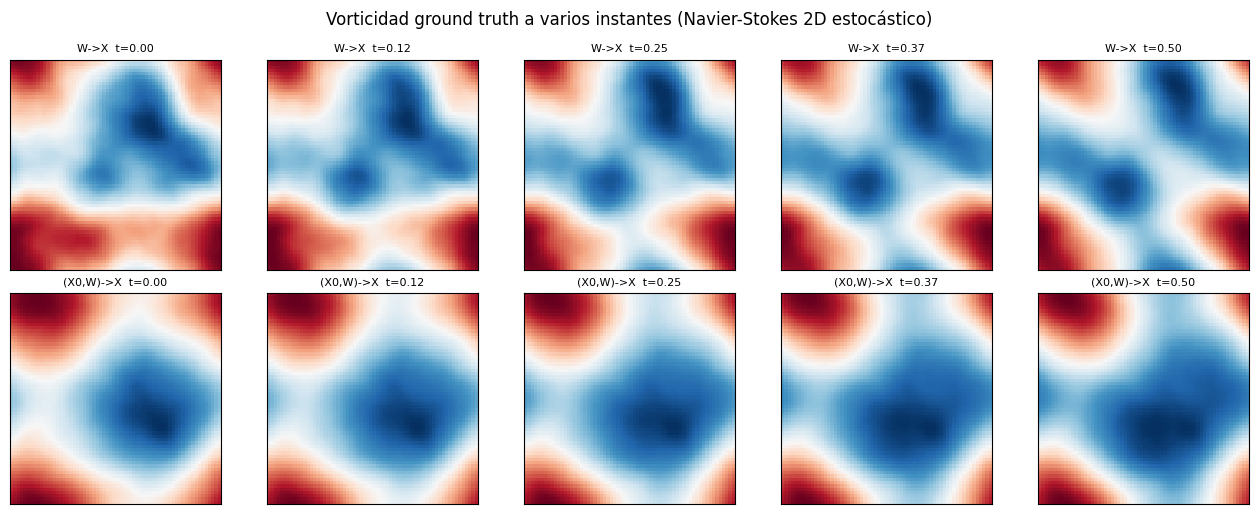

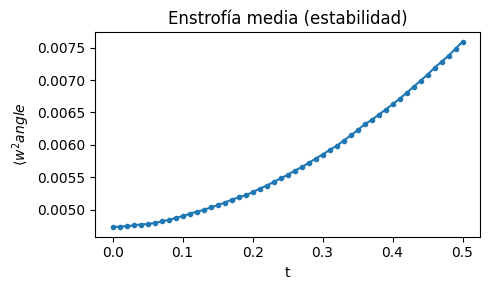

rango vorticidad final: -0.199 0.239


: 

In [ ]:
# ---------------- Comprobación visual: evolución de la vorticidad (cf. Fig. 3 del paper) ----------------
idx = [int(k) for k in np.linspace(0, Nt, 5)]
fig, axs = plt.subplots(2, 5, figsize=(13, 5.2))
for col, ti in enumerate(idx):
    for row, (dat, ttl) in enumerate([(Xtr, "W->X"), (Xtr2, "(X0,W)->X")]):
        im = axs[row, col].imshow(dat[0, ti], origin="lower", cmap="RdBu_r")
        axs[row, col].set_title(f"{ttl}  t={ti*dt*(math.ceil(T/dt)//rec):.2f}", fontsize=8)
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
plt.suptitle("Vorticidad ground truth a varios instantes (Navier-Stokes 2D estocástico)")
plt.tight_layout(); plt.savefig("ns_ground_truth.pdf"); plt.show()

# enstrofía media (||w||^2) en el tiempo: chequeo de estabilidad del solver
ens = (Xtr ** 2).mean(axis=(0, 2, 3))
plt.figure(figsize=(5, 3))
plt.plot(np.arange(Nt + 1) * (T / rec), ens, "o-", ms=3)
plt.xlabel("t"); plt.ylabel(r"$\langle w^2angle$"); plt.title("Enstrofía media (estabilidad)")
plt.tight_layout(); plt.show()
print("rango vorticidad final:", round(float(Xtr[:, -1].min()), 3), round(float(Xtr[:, -1].max()), 3))
